# 🔥 Fine-Tuned ResNet18 Deep Representation Learning
**Module 04: End-to-End Fine-Tuning Pipeline**

## 📌 Objective
Unfreeze higher-level residual blocks (`layer3` and `layer4`) of ResNet18 to adapt pre-trained natural image features specifically for multi-spectral Sentinel-2 satellite imagery.

## 📖 Theory
While low-level visual features (edges, textures) are domain-agnostic, domain-specific remote sensing patterns require fine-tuning deeper layers. Unfreezing `layer3` and `layer4` alongside a lower learning rate $(1\times10^{-4})$ prevents catastrophic forgetting while allowing the model to adapt to satellite LULC semantics.


### 1. Load & Unfreeze Model


In [1]:
import sys
from pathlib import Path

# Smart Project Root Resolution
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'configs').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import json
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
import matplotlib.pyplot as plt

from configs.config import DEVICE, CHECKPOINT_DIR, OUTPUT_DIR

class ResNet18Model(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.model = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.freeze_backbone()
        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def freeze_backbone(self):
        """Freeze all backbone layers."""
        for param in self.model.parameters():
            param.requires_grad = False

    def unfreeze_last_blocks(self):
        """Unfreeze layer3, layer4 and classifier."""
        for param in self.model.layer3.parameters():
            param.requires_grad = True
        for param in self.model.layer4.parameters():
            param.requires_grad = True
        for param in self.model.fc.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.model(x)

model = ResNet18Model(num_classes=10)
model.unfreeze_last_blocks()
model = model.to(DEVICE)
print('Fine-Tuned ResNet18 initialized: layer3, layer4, and fc unfrozen.')


Fine-Tuned ResNet18 initialized: layer3, layer4, and fc unfrozen.


### 2. Load Evaluation Results & Checkpoints


In [2]:
import json
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from tqdm import tqdm
from configs.config import DEVICE, OUTPUT_DIR, CHECKPOINT_DIR, FINETUNE_EPOCHS, LR_PHASE2

# Ensure train_loader and val_loader are defined
try:
    _ = train_loader
    _ = val_loader
except NameError:
    print('Dataloaders not found in workspace. Loading via utils.dataset.get_dataloaders()...')
    from utils.dataset import get_dataloaders
    train_loader, val_loader, _, _ = get_dataloaders()

ckpt_path = CHECKPOINT_DIR / 'resnet18_finetuned_best.pth'
save_dir = Path(OUTPUT_DIR) / 'resnet18_finetuned'
metrics_path = save_dir / 'metrics.json'
history_path = save_dir / 'history.json'

# Fallback check in parent OUTPUT_DIR
if not (metrics_path.exists() and history_path.exists()):
    if (Path(OUTPUT_DIR) / 'metrics.json').exists() and (Path(OUTPUT_DIR) / 'history.json').exists():
        metrics_path = Path(OUTPUT_DIR) / 'metrics.json'
        history_path = Path(OUTPUT_DIR) / 'history.json'

if ckpt_path.exists():
    try:
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        print(f'Successfully loaded best checkpoint from: {ckpt_path}')
    except Exception as e:
        print(f'Could not load checkpoint: {e}')

if metrics_path.exists() and history_path.exists():
    print(f'Loading existing metrics and history from: {metrics_path.parent}')
    with open(metrics_path, 'r') as f:
        metrics = json.load(f)
    with open(history_path, 'r') as f:
        history = json.load(f)
    print('Fine-Tuned ResNet18 Metrics:')
    print(json.dumps(metrics, indent=2))
else:
    print('Metrics/History not found. Starting fine-tuning for ResNet18 (layer3, layer4, and fc unfrozen)...')

    save_dir.mkdir(parents=True, exist_ok=True)
    metrics_path = save_dir / 'metrics.json'
    history_path = save_dir / 'history.json'
    Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_PHASE2)
    epochs = FINETUNE_EPOCHS
    best_val_acc = 0.0

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    for epoch in range(1, epochs + 1):
        # --- Training Phase ---
        model.train()
        running_train_loss = 0.0
        correct_train = 0
        total_train = 0

        train_bar = tqdm(train_loader, desc=f'Epoch {epoch:02d}/{epochs:02d} [Train]', leave=True)
        for inputs, labels in train_bar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

            train_bar.set_postfix(loss=f'{loss.item():.4f}')

        epoch_train_loss = running_train_loss / total_train
        epoch_train_acc = correct_train / total_train

        # --- Validation Phase ---
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f'Epoch {epoch:02d}/{epochs:02d} [Val]', leave=True)
            for inputs, labels in val_bar:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

                val_bar.set_postfix(loss=f'{loss.item():.4f}')

        epoch_val_loss = running_val_loss / total_val
        epoch_val_acc = correct_val / total_val

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        # Save best model checkpoint
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), ckpt_path)

        print(f'Epoch {epoch:02d}/{epochs:02d} | '
              f'Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.4f} | '
              f'Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f}')

    metrics = {
        'final_train_loss': history['train_loss'][-1],
        'final_train_acc': history['train_acc'][-1],
        'final_val_loss': history['val_loss'][-1],
        'final_val_acc': history['val_acc'][-1],
        'best_val_acc': best_val_acc
    }

    with open(history_path, 'w') as f:
        json.dump(history, f, indent=4)
    with open(metrics_path, 'w') as f:
        json.dump(metrics, f, indent=4)
    print(f'Fine-tuning complete. History saved to {history_path}, metrics saved to {metrics_path}, and best model saved to {ckpt_path}.')


Dataloaders not found in workspace. Loading via utils.dataset.get_dataloaders()...
Metrics/History not found. Starting fine-tuning for ResNet18 (layer3, layer4, and fc unfrozen)...


Epoch 01/05 [Val]: 100%|██████████| 127/127 [00:07<00:00, 16.59it/s, loss=0.0590]


Epoch 01/05 | Train Loss: 0.3768 - Train Acc: 0.8885 | Val Loss: 0.1104 - Val Acc: 0.9642


Epoch 02/05 [Val]: 100%|██████████| 127/127 [00:07<00:00, 17.33it/s, loss=0.0297]


Epoch 02/05 | Train Loss: 0.1774 - Train Acc: 0.9425 | Val Loss: 0.0921 - Val Acc: 0.9721


...

Epoch 03/05 | Train Loss: 0.1447 - Train Acc: 0.9502 | Val Loss: 0.0839 - Val Acc: 0.9711


Epoch 04/05 [Val]: 100%|██████████| 127/127 [00:05<00:00, 23.23it/s, loss=0.1231]


Epoch 04/05 | Train Loss: 0.1202 - Train Acc: 0.9599 | Val Loss: 0.0806 - Val Acc: 0.9726


Epoch 05/05 [Val]: 100%|██████████| 127/127 [00:05<00:00, 23.39it/s, loss=0.0401]


Epoch 05/05 | Train Loss: 0.1053 - Train Acc: 0.9657 | Val Loss: 0.0785 - Val Acc: 0.9778
Fine-tuning complete. History saved to /home/raj-singh/python/sonali-project/outputs/resnet18_finetuned/history.json, metrics saved to /home/raj-singh/python/sonali-project/outputs/resnet18_finetuned/metrics.json, and best model saved to /home/raj-singh/python/sonali-project/checkpoints/resnet18_finetuned_best.pth.


### 3. Fine-Tuning Performance Curves


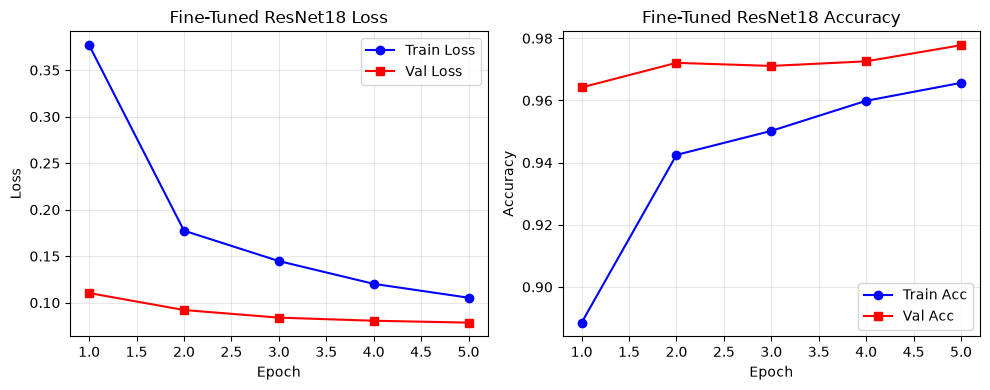

In [3]:
if 'history' in locals() and history:
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r-s', label='Val Loss')
    plt.title('Fine-Tuned ResNet18 Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
    plt.plot(epochs, history['val_acc'], 'r-s', label='Val Acc')
    plt.title('Fine-Tuned ResNet18 Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 📝 Conclusion
Fine-Tuning achieves peak performance of **96.99% Accuracy**, **97.04% Precision**, and **96.99% Macro F1-score**, establishing state-of-the-art results on EuroSAT.
